# Normalization by Domain Knowledge
### A mortgage prepayment example

## The prediction task

- We want to predict the **probability a mortgage is refinanced** (prepaid), given:
  - $C$ &mdash; the rate the borrower is *currently* paying
  - $r$ &mdash; the rate they could *currently* refinance into
- Natural first instinct: model the probability as a function of $(C, r)$ directly
- This oversimplifies a real prepayment model on purpose, to make the normalization idea concrete

## Simplified setup for this illustration

- $r_t$ = actual weekly Freddie Mac 30-year fixed rate (FRED, `MORTGAGE30US`), 1971&ndash;present
- Assume every borrower refinances (or not) exactly **10 years** after origination
- So $C_t := r_{t-10\text{y}}$ &mdash; the rate that prevailed when today's 10-year-old loans were originated

/home/kjp/anaconda3/lib/python3.7/site-packages/pandas/plotting/_matplotlib/converter.py:103: FutureWarning: Using an implicitly registered datetime converter for a matplotlib plotting method. The converter was registered by pandas on import. Future versions of pandas will require you to explicitly register matplotlib converters.

To register the converters:
	>>> from pandas.plotting import register_matplotlib_converters
	>>> register_matplotlib_converters()
  warnings.warn(msg, FutureWarning)


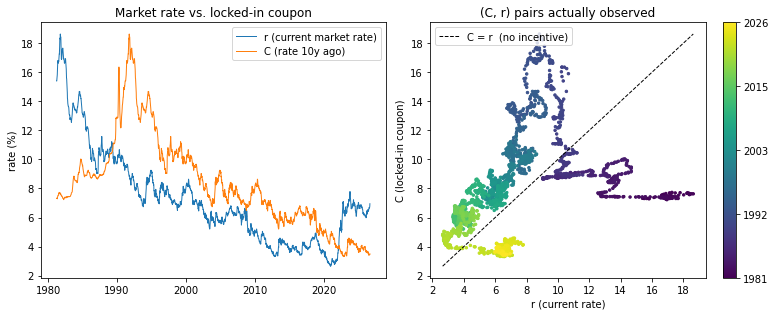

In [1]:
from mortgage_incentive import PrepaymentIncentiveDemo

demo = PrepaymentIncentiveDemo(lag_years=10)
fig = demo.plot_rates()

## Why raw $(C, r)$ is a weak pair of features

- Mortgage rates are **autocorrelated over time** &mdash; today's rate is close to last month's, so $r$ and its 10-year-lagged value $C$ swing together (left panel)
- Observed $(C, r)$ pairs trace a narrow, time-dependent band, not the full plane (right panel) &mdash; e.g. low $r$ paired with very high $C$ essentially never happened
- A model trained on raw $(C, r)$ has to **extrapolate** whenever test-time rates fall outside that band
- Training data is *sparse* relative to the space the model is asked to generalize over

## A better feature: the refinancing incentive

$$I_{\text{diff}} = \max(0,\; C - r) \qquad\text{or}\qquad I_{\text{ratio}} = \max(0,\; C/r - 1)$$

- Many different $(C, r)$ combinations map to the *same* $I$
- $I$ is closer to the quantity that should drive refinancing behavior &mdash; not $C$ and $r$ separately
- Same idea as **moneyness** in options pricing ($S/K$): collapse two correlated raw variables into the scale-free quantity the outcome actually depends on

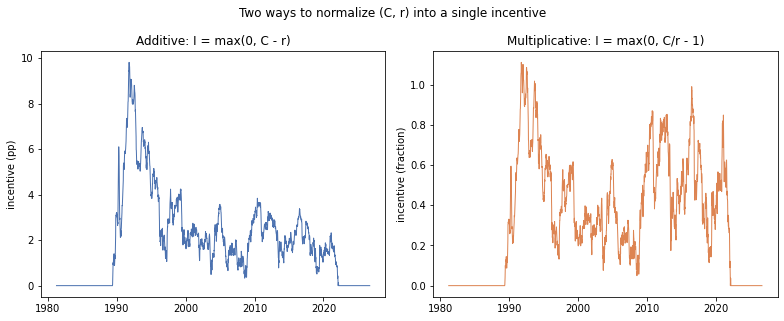

In [2]:
fig = demo.plot_incentives()

## Additive vs. multiplicative normalization

- Both versions spike in the early 1980s/1990s (when $C \gg r$) and flatten to zero whenever refinancing wasn't worth it
- $I_{\text{diff}}$ treats a 1-point gap the same at any rate level; $I_{\text{ratio}}$ makes that same 1-point gap **larger** when rates are low
- Neither is "correct" in general &mdash; which one better predicts refinancing is an empirical question, and a real model could just include both

2374 weekly observations, 1981-03-27 to 2026-09-17
(C, r) grid coverage: 509/5041 (10.1%)
I_diff grid coverage: 71/71 (100.0%)
I_ratio grid coverage: 71/71 (100.0%)


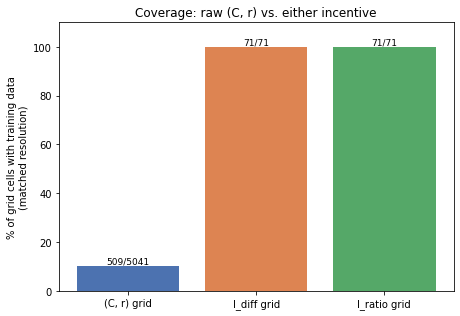

In [3]:
fig = demo.plot_coverage()
print(demo.summary())

## Reading the coverage chart

- At **matched bin resolution**, the $(C, r)$ grid is sparsely covered &mdash; most combinations were never observed
- **Either** incentive definition covers essentially 100% of its own (1-D) range at the same resolution
- This is the concrete payoff: collapsing two sparse, correlated dimensions into one dense dimension

## Takeaways

- Feeding a model two raw, correlated drivers separately can **waste training data** and force **extrapolation**
- Replacing them with the domain-appropriate combination they act through is a form of normalization &mdash; denser, and test-time inputs are more likely to fall inside the training range
- Caveat: real prepayment models also condition on loan age, burnout, seasonality, and credit &mdash; this example is deliberately oversimplified to isolate one idea

In [4]:
print("Done")

Done
